# Endogenous Investment via Capital *and* Labour — a Normalised-CES Core

This notebook illustrates the current model: **normalised-CES** production
(`sigma` = elasticity of substitution between capital and labour) with an
**endogenous labour market** (fixed wage `w_bar`, `L = min(L_demand, L_profitmax, N)`)
and internal retained-earnings financing.

Two experiments:

1. a retention-ratio sweep at `sigma = 1` (the Cobb-Douglas case) — which is **wage-led**;
2. the `(sigma, rho)` **sign frontier** — where the sign of `dY/drho` flips with `sigma`.

The quantitative robustness layer (bootstrap CIs on `sigma*`, support/anchor
sensitivity, 20 seeds) lives in `results/ces_b05_*.csv`, produced reproducibly by
`scripts/run_brief05.py`. Here we run small (3-seed) sweeps just to draw the picture.
All runs use `c0 = 1.0` (the headline demand setting).

In [1]:
import os, sys

# Locate the repo root whether the kernel starts here or in notebooks/.
here = os.getcwd()
REPO = here if os.path.isdir(os.path.join(here, "src")) else os.path.abspath(os.path.join(here, ".."))
sys.path.insert(0, os.path.join(REPO, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from experiment import run_experiment, sigma_rho_sweep, sweep_derivatives, sign_frontier, plot_sign_frontier

STEPS, SEEDS, TAIL = 2000, 3, 50
print("repo root:", REPO)

repo root: C:\Users\recursivechaos\Documents\ABM


## 1. At `sigma = 1` (Cobb-Douglas), retention is wage-led

More retention builds capital, but with capital and labour substitutable the extra
capital *displaces workers*: employment falls, unemployment rises, the wage bill and
wage share fall, and — because workers consume more than capitalists — output falls.

 rho      Y     U  wage_share       K
0.35 95.278 0.413       0.554 251.736
0.40 90.623 0.485       0.511 281.194
0.45 88.651 0.527       0.481 311.521
0.50 87.847 0.561       0.450 351.586
0.55 86.928 0.587       0.428 385.451
0.60 88.519 0.593       0.413 420.894
0.65 84.918 0.627       0.395 441.679


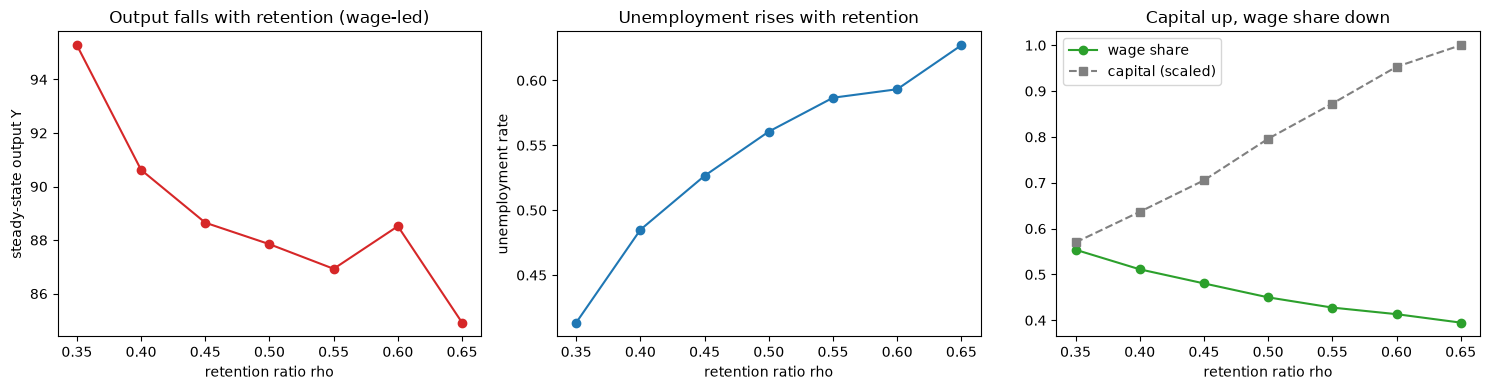

In [2]:
rhos = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
rows = []
for rho in rhos:
    panel = run_experiment(rho, steps=STEPS, seeds=SEEDS, sigma=1.0, c0=1.0)
    s = panel[panel.index >= STEPS - TAIL].drop(columns="Seed").mean()
    rows.append(dict(rho=rho, Y=s["Output"], U=s["Unemployment_Rate"],
                     wage_share=s["Wage_Share"], K=s["Total_Capital"]))
sweep1 = pd.DataFrame(rows)
print(sweep1.round(3).to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(sweep1["rho"], sweep1["Y"], "o-", color="C3")
ax[0].set(xlabel="retention ratio rho", ylabel="steady-state output Y",
          title="Output falls with retention (wage-led)")
ax[1].plot(sweep1["rho"], sweep1["U"], "o-", color="C0")
ax[1].set(xlabel="retention ratio rho", ylabel="unemployment rate",
          title="Unemployment rises with retention")
ax[2].plot(sweep1["rho"], sweep1["wage_share"], "o-", color="C2", label="wage share")
ax[2].plot(sweep1["rho"], sweep1["K"] / sweep1["K"].max(), "s--", color="0.5",
           label="capital (scaled)")
ax[2].set(xlabel="retention ratio rho", title="Capital up, wage share down")
ax[2].legend()
fig.tight_layout()
fig.savefig(os.path.join(REPO, "retention_sweep.png"), dpi=150)
plt.show()

## 2. The `(sigma, rho)` sign frontier

`sigma` sets how easily capital substitutes for labour, and that decides the sign of
`dY/drho`. Below a threshold `sigma*` retention *raises* output (the substitution is
weak, the supply channel wins); above it retention *lowers* output (the wage-led
channel wins). `sigma = 1` sits above `sigma*`, which is why §1 was wage-led; the
empirically estimated range `sigma` 0.40–0.60 sits below it.

In [3]:
grid = sigma_rho_sweep(steps=STEPS, seeds=SEEDS, c0=1.0)
deriv = sweep_derivatives(grid, viable_only=True)
frontier = sign_frontier(deriv)
print("sigma* by rho (linear interpolation between adjacent sigma cells):")
print(frontier[["rho", "sigma_star"]].round(3).to_string(index=False)
      if len(frontier) else "no sign change in the tested range")

plot_sign_frontier(grid, deriv, path=os.path.join(REPO, "ces_sign_frontier.png"))
print("saved ces_sign_frontier.png")

sigma* by rho (linear interpolation between adjacent sigma cells):
 rho  sigma_star
 0.4       0.567
 0.5       0.878
 0.6       1.310


saved ces_sign_frontier.png


> **Nota sui valori.** I `sigma*` stampati sopra usano lo stimatore del brief 04 (interpolazione lineare fra celle adiacenti, **3 seed**) e servono solo a disegnare la frontiera; i valori **canonici**, con intervallo di confidenza bootstrap (**20 seed**, slope OLS sul supporto viable comune), sono in `results/ces_b05_sigma_star.csv` (sigma* ~ 0.654 [0.616, 0.691] a c0 = 1.0) e riassunti nel README (§2).

## 3. Reading of the results

* **The regime is demand-constrained** almost everywhere in the viable cells; `sigma`
  acts *inside* the regime rather than switching it.
* **`sigma = 1` is wage-led** (§1). The sign of `dY/drho` **turns at `sigma*`** (§2),
  and the empirical range `sigma` 0.40–0.60 sits **below** `sigma*` — so the wage-led
  headline rests on the one `sigma` the literature rejects.
* **`dU/drho` has a different, lower frontier**: in a band around `sigma ~ 0.3–0.7`,
  output and unemployment rise together — growth with technological unemployment.
* **`sigma*` is a frontier, not a number**: it moves with `rho` (curvature), the support,
  and the normalisation anchor. The bootstrap CIs and these sensitivities are quantified
  over 20 seeds in `results/ces_b05_*.csv` (`scripts/run_brief05.py`), and summarised in
  the README.
* The model has **multiple equilibria and a viability threshold near `rho ~ 0.30`**;
  `initial_capital` selects the basin and is held fixed. Collapsed cells are an outcome.